# Chopp & Cia · 06 — Árvore de Decisão

**Projeto Integrador VI** · FATEC Votorantim · 2º Semestre/2026

Treina e compara variações de Árvore de Decisão sobre o split do notebook 04.
Escolhe um campeão por **um único critério** (MCC por validação cruzada), e o
avalia com intervalos de confiança — a classe positiva é maioria, então
accuracy e AUC isoladas enganam.

A vantagem sobre a Regressão Logística: a regra pode ser **lida**. Este
notebook soma, ao final, o desenho da árvore campeã e as regras em texto.

| | |
|:---|:---|
| **Entrada** | `dataset_split_v<DATA_VERSION>` do notebook 04 |
| **Saída** | tabela e gráficos de comparação · modelo campeão (`.pkl` local / MLflow no Databricks) |
| **Ambiente** | Windows local ou Databricks |

### O painel `ESTUDO`

Um lote por execução. Troque `ESTUDO` e rode de novo:

| `ESTUDO` | Varre | Responde |
|:---|:---|:---|
| `hiperparametros` | um parâmetro | qual configuração aprende melhor |
| `grade_cruzada` | produto de dois+ parâmetros | há interação entre eles? |
| `ablacao` | remove features derivadas do alvo | quanto do desempenho vem do vazamento |
| `baseline_unico` | nada | rodada de referência |

`elegibilidade` e `janela_temporal` não vivem mais aqui: são parâmetros do
notebook 04 (que decide quais linhas existem). Para testar outro `min_compras`,
gere outro `dataset_split` lá e aponte este notebook para ele.

### Por que o campeão sai da CV

Com poucos casos da classe rara no teste, escolher entre 7 variações pelo
`test_*` transforma o holdout em parte da escolha — e ele deixa de estimar
generalização. `SELECAO['origem'] = 'cv'` é o padrão; o holdout é lido só uma
vez, no fim, sobre o campeão já eleito.

## 1. Painel de controle

Tudo que muda o resultado mora nesta célula. As seguintes só leem daqui.

In [ ]:
import itertools
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, balanced_accuracy_score,
    matthews_corrcoef, brier_score_loss,
)

# ── Entrada e saída ──────────────────────────────────────────────────────────
CAMINHO_CSV_SPLIT = r""
PASTA_SAIDA = r""          # vazio: mesma pasta do split
TABELA_SPLIT = "projetointegrador.projetointegrador.dataset_split_v1_0"  # Databricks

RANDOM_STATE = 42          # semente única, propagada a CV e estimadores —
                            # reprodutibilidade, não hiperparâmetro.

try:
    spark                                                      # noqa: F821
    EM_DATABRICKS = True
except NameError:
    EM_DATABRICKS = False

if EM_DATABRICKS:
    import mlflow
    import mlflow.sklearn
    from mlflow.models import infer_signature
    EXPERIMENT_NAME = "/Users/brunofsaraujo@hotmail.com/Chopp_Cia_Experimentos"
    NOME_REGISTRADO = "workspace.default.chopp_risco_regressao"

# ── O estudo — a pergunta que este lote responde ─────────────────────────────
ESTUDO = "hiperparametros"
NOTA_ESTUDO = (
    "Varredura de max_depth — o único hiperparâmetro que governa o trade-off "
    "entre decorar o treino e generalizar. Árvore rasa erra por simplicidade; "
    "árvore funda decora casos únicos do treino e falha no teste."
)

GRADES = {
    "hiperparametros": {"parametro": "max_depth", "valores": [2, 3, 4, 5, 6, 8, 10, None]},
    "grade_cruzada": {"parametros": {"max_depth": [3, 5, 8], "min_samples_leaf": [1, 5, 10]}},
    "ablacao": {
        "conjuntos": [
            {"nome": "completo (todas as features)", "remover": []},
            {"nome": "sem MEDIA_DIAS_ATRASO_PAG", "remover": ["MEDIA_DIAS_ATRASO_PAG"]},
            {"nome": "sem MEDIA_DIAS_ATRASO_COM", "remover": ["MEDIA_DIAS_ATRASO_COM"]},
            {"nome": "sem ambas as MEDIA_DIAS_ATRASO",
             "remover": ["MEDIA_DIAS_ATRASO_PAG", "MEDIA_DIAS_ATRASO_COM"]},
        ],
    },
    "baseline_unico": {},
}
GRADE_ESTUDO = GRADES.get(ESTUDO, {})

# ── Hiperparâmetros-base do modelo ────────────────────────────────────────────
NOME_MODELO, SLUG_MODELO, COR_MODELO = "Árvore de Decisão", "arvore_decisao", "#1baf7a"
CLASSE_MODELO = DecisionTreeClassifier

HP_BASE = {
    "max_depth": 6,               # None = sem limite ⇒ decora o treino
    "min_samples_split": 2,
    "min_samples_leaf": 1,        # folha com poucos clientes é coincidência, não regra
    "criterion": "gini",
    "class_weight": "balanced",   # compensa o desbalanceamento sem reamostrar
}

# ── Pré-processamento ─────────────────────────────────────────────────────────
PREPROC = {
    "scaler_numerico": "none",       # árvore não usa distância — escala não muda a partição
    "onehot_drop": None,             # colinearidade não afeta split por impureza
    "onehot_handle_unknown": "ignore",   # categoria nova em produção não quebra
}

# ── Validação cruzada ──────────────────────────────────────────────────────────
CV = {"n_splits": 5, "shuffle": True, "return_train_score": True}
SCORING_CV = {
    "roc_auc": "roc_auc", "average_precision": "average_precision",
    "f1": "f1", "recall": "recall", "precision": "precision",
    "balanced_accuracy": "balanced_accuracy", "matthews_corrcoef": "matthews_corrcoef",
}

# ── Seleção do campeão ────────────────────────────────────────────────────────
# MCC, não AUC: só sobe quando AMBAS as classes são bem classificadas. O
# baseline majoritário tem MCC = 0 por construção — um piso claro de leitura.
SELECAO = {
    "metrica": "MCC", "origem": "cv", "maior_melhor": True,
    "criterio_desempate": "Balanced_Accuracy",
}
BASELINE_ATIVO = True   # DummyClassifier(most_frequent) — âncora obrigatória

THRESHOLD = {
    "classificacao": 0.50,
    "faixa_baixo": 0.35, "faixa_medio": 0.65,     # tradução prob. → BAIXO/MÉDIO/ALTO
    "sweep_inicio": 0.20, "sweep_fim": 0.80, "sweep_passo": 0.05,
}
METAS_KPI = {"auc_roc": 0.75, "recall_classe1": 0.70, "accuracy": 0.65}
IC_Z = 1.96   # 95% de confiança

CSV_SAIDA = {"sep": ";", "encoding": "utf-8-sig", "index": False}

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

if ESTUDO not in GRADES:
    raise ValueError(f"ESTUDO='{ESTUDO}' sem grade em GRADES. Opções: {list(GRADES)}")

print(f"Ambiente : {'Databricks' if EM_DATABRICKS else 'Local'}")
print(f"Modelo   : {NOME_MODELO}")
print(f"Estudo   : {ESTUDO}")
print(f"Seleção  : {SELECAO['metrica']} ({SELECAO['origem']}), desempate {SELECAO['criterio_desempate']}")

Ambiente : Local
Modelo   : Árvore de Decisão
Estudo   : hiperparametros
Seleção  : MCC (cv), desempate Balanced_Accuracy


## 2. Carga do split

Nenhum `train_test_split` aqui: a partição foi decidida no notebook 04 e é
lida como está — é o que garante que 05, 06 e 07 vejam as **mesmas linhas**.

In [2]:
if EM_DATABRICKS:
    df_split = spark.table(TABELA_SPLIT).toPandas()             # noqa: F821
    origem = TABELA_SPLIT
else:
    if not CAMINHO_CSV_SPLIT.strip():
        raise ValueError("Preencha CAMINHO_CSV_SPLIT com o CSV do notebook 04.")
    caminho_split = Path(CAMINHO_CSV_SPLIT.strip())
    if not caminho_split.exists():
        raise FileNotFoundError(f"CSV não encontrado: {caminho_split}")
    df_split = pd.read_csv(caminho_split, sep=";", encoding="utf-8-sig", low_memory=False)
    origem = caminho_split.name

df_split.columns = [str(c).strip().upper() for c in df_split.columns]

if "_SPLIT" not in df_split.columns:
    raise KeyError("Coluna _SPLIT ausente — esta tabela não veio do notebook 04.")

DATA_VERSION = (
    str(df_split["_DATA_VERSION"].iloc[0]) if "_DATA_VERSION" in df_split.columns else "desconhecida"
)
TARGET = "ALTO_RISCO"
if TARGET not in df_split.columns:
    raise KeyError(f"Alvo '{TARGET}' ausente em {origem}.")

# Identidade: a chave, mais qualquer coluna que identifique a PESSOA — por
# padrão, não por lista fixa, para o caso de uma carga futura reintroduzir uma.
PADROES_NOMINAIS = ("NOME", "NM_", "FANTASIA", "RAZAO", "CPF", "CNPJ", "EMAIL",
                    "TELEFONE", "ENDERECO")
IDENTIDADE = {"ID_PESSOA"} | {
    c for c in df_split.columns if any(p in c.upper() for p in PADROES_NOMINAIS)
}
nominais = sorted(IDENTIDADE - {"ID_PESSOA"})
if nominais:
    raise ValueError(f"Identificação nominal na tabela de split: {nominais}. Não pode virar feature.")

META = {"_SPLIT", "_DATA_VERSION"}
todas = [c for c in df_split.columns if c not in META | IDENTIDADE | {TARGET}]
FEATURES_CAT = [c for c in todas if df_split[c].dtype == object]
FEATURES_NUM = [c for c in todas if c not in FEATURES_CAT]
for c in FEATURES_NUM:
    df_split[c] = pd.to_numeric(df_split[c], errors="coerce")
df_split[TARGET] = pd.to_numeric(df_split[TARGET], errors="coerce").astype(int)
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT

nan_num = [c for c in FEATURES_NUM if df_split[c].isna().any()]
if nan_num:
    raise ValueError(f"Features numéricas com NaN: {nan_num}. Reexecute o notebook 04.")

tr, te = df_split[df_split["_SPLIT"] == "train"], df_split[df_split["_SPLIT"] == "test"]
X_train, y_train = tr[ALL_FEATURES].copy(), tr[TARGET].copy()
X_test, y_test = te[ALL_FEATURES].copy(), te[TARGET].copy()

n_pos_teste, n_neg_teste = int((y_test == 1).sum()), int((y_test == 0).sum())
N_MINORIA_TESTE = min(n_pos_teste, n_neg_teste)

print(f"DATA_VERSION : {DATA_VERSION}")
print(f"X_train : {X_train.shape[0]:>5,} × {X_train.shape[1]:>2}   prevalência {y_train.mean():.1%}")
print(f"X_test  : {X_test.shape[0]:>5,} × {X_test.shape[1]:>2}   prevalência {y_test.mean():.1%}")
print(f"Features: {len(ALL_FEATURES)} ({len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat)")
print(f"\nClasse minoritária no teste: {N_MINORIA_TESTE} casos", end="")
if N_MINORIA_TESTE < 20:
    print(f" — um cliente reclassificado move a métrica ~{100 / N_MINORIA_TESTE:.1f}p.")
else:
    print()

DATA_VERSION : 1.0
X_train :   895 × 15   prevalência 89.9%
X_test  :   384 × 15   prevalência 89.8%
Features: 15 (12 num + 3 cat)

Classe minoritária no teste: 39 casos


## 3. Motor de métricas

A classe positiva é **maioria**: prever "todos são risco" já entrega accuracy
alta e recall perfeito sem o modelo ter aprendido nada. A classe rara é a **0**
(bom pagador) — e é ela que o negócio precisa reconhecer para não recusar
crédito a quem paga. Por isso o conjunto inclui MCC, balanced accuracy e a
specificity (recall da classe 0), não só as métricas tradicionais.

IC de Wilson para proporções (apropriado a `n` pequeno) e Hanley & McNeil para
a AUC. Um IC largo não é defeito do relatório — é o que os dados sustentam.

In [3]:
def ic_wilson(acertos, n, z=IC_Z):
    if n == 0:
        return (float("nan"), float("nan"))
    p = acertos / n
    den = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    margem = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return (max(0.0, centro - margem), min(1.0, centro + margem))


def ic_auc_hanley(auc, n_pos, n_neg, z=IC_Z):
    if n_pos == 0 or n_neg == 0:
        return (float("nan"), float("nan"), float("nan"))
    q1, q2 = auc / (2 - auc), 2 * auc**2 / (1 + auc)
    se = float(np.sqrt(
        (auc * (1 - auc) + (n_pos - 1) * (q1 - auc**2) + (n_neg - 1) * (q2 - auc**2))
        / (n_pos * n_neg)
    ))
    return (max(0.0, auc - z * se), min(1.0, auc + z * se), se)


def avaliar_no_teste(pipeline, X_te, y_te, threshold):
    """Conjunto completo de métricas de holdout, para AMBAS as classes."""
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    report = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    c1 = report.get("1", {"precision": 0, "recall": 0, "f1-score": 0})
    c0 = report.get("0", {"precision": 0, "recall": 0, "f1-score": 0})

    auc = float(roc_auc_score(y_te, y_proba))
    n_pos, n_neg = int((y_te == 1).sum()), int((y_te == 0).sum())
    auc_lo, auc_hi, auc_se = ic_auc_hanley(auc, n_pos, n_neg)

    tp = int(((y_te == 1) & (y_pred == 1)).sum())
    tn = int(((y_te == 0) & (y_pred == 0)).sum())
    rec1_lo, rec1_hi = ic_wilson(tp, n_pos)
    spec_lo, spec_hi = ic_wilson(tn, n_neg)
    ap_c0 = float(average_precision_score(1 - np.asarray(y_te), 1 - y_proba))

    return {
        "AUC": auc, "AUC_ic_low": float(auc_lo), "AUC_ic_high": float(auc_hi), "AUC_se": float(auc_se),
        "AP": float(average_precision_score(y_te, y_proba)), "AP_classe0": ap_c0,
        "F1": float(c1["f1-score"]), "Recall": float(c1["recall"]),
        "Recall_ic_low": float(rec1_lo), "Recall_ic_high": float(rec1_hi),
        "Precisao": float(c1["precision"]),
        "Specificity": float(c0["recall"]),
        "Specificity_ic_low": float(spec_lo), "Specificity_ic_high": float(spec_hi),
        "Precisao_classe0": float(c0["precision"]), "F1_classe0": float(c0["f1-score"]),
        "Accuracy": float(report["accuracy"]),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_te, y_pred)),
        "MCC": float(matthews_corrcoef(y_te, y_pred)),
        "Brier": float(brier_score_loss(y_te, y_proba)),
        "threshold": float(threshold), "y_pred": y_pred, "y_proba": y_proba,
    }


print(f"Motor de métricas pronto — IC de Wilson e Hanley & McNeil, z={IC_Z}")

Motor de métricas pronto — IC de Wilson e Hanley & McNeil, z=1.96


## 4. Fábrica de pipeline

Lê o painel; não escreve hiperparâmetro nenhum. `clone()` no pré-processador:
cada pipeline recebe a própria cópia não-treinada — sem isso, as variações do
lote compartilhariam a instância por referência.

In [4]:
_SCALERS = {"standard": StandardScaler, "minmax": MinMaxScaler, "robust": RobustScaler, "none": None}


def build_pipeline(clf, features_num=None, features_cat=None):
    fn = FEATURES_NUM if features_num is None else features_num
    fc = FEATURES_CAT if features_cat is None else features_cat
    classe_scaler = _SCALERS[PREPROC["scaler_numerico"]]
    step_num = "passthrough" if classe_scaler is None else classe_scaler()
    step_cat = OneHotEncoder(handle_unknown=PREPROC["onehot_handle_unknown"],
                             drop=PREPROC["onehot_drop"], sparse_output=False)
    prep = ColumnTransformer(
        transformers=[("num", step_num, fn), ("cat", step_cat, fc)],
        remainder="drop", verbose_feature_names_out=False,
    )
    return Pipeline(steps=[("prep", clone(prep)), ("clf", clf)])


def build_classifier(params):
    p = dict(params)
    p["random_state"] = RANDOM_STATE
    return CLASSE_MODELO(**p)


_demo = build_pipeline(build_classifier(HP_BASE))
print(f"Pipeline: {PREPROC['scaler_numerico']} ({len(FEATURES_NUM)} num) + "
      f"onehot({len(FEATURES_CAT)} cat) + {CLASSE_MODELO.__name__}")

Pipeline: none (12 num) + onehot(3 cat) + DecisionTreeClassifier


## 5. Motor de experimentos

`treinar_variacao()` roda CV, o gap treino−validação (diagnóstico de
overfitting), o holdout com IC, e a varredura de limiar **out-of-fold** — nunca
no holdout: escolher o corte olhando o teste é tuning no próprio teste, e o
"ótimo" ali é ruído.

`treinar_baseline()` é a âncora obrigatória: sem ela nenhuma métrica significa
nada. MCC do baseline é 0 por construção — o piso claro de leitura.

In [5]:
def _cv():
    return StratifiedKFold(n_splits=CV["n_splits"], shuffle=CV["shuffle"], random_state=RANDOM_STATE)


def sweep_threshold(pipeline, X_tr, y_tr):
    """Varre a grade de limiares sobre predições OUT-OF-FOLD do treino. Retorna (thr, mcc)."""
    grade = np.round(
        np.arange(THRESHOLD["sweep_inicio"], THRESHOLD["sweep_fim"] + THRESHOLD["sweep_passo"] / 2,
                  THRESHOLD["sweep_passo"]), 4,
    )
    proba_oof = cross_val_predict(pipeline, X_tr, y_tr, cv=_cv(), method="predict_proba")[:, 1]
    y_oof = np.asarray(y_tr)
    melhor = (THRESHOLD["classificacao"], -np.inf)
    for thr in grade:
        pred = (proba_oof >= thr).astype(int)
        mcc = matthews_corrcoef(y_oof, pred)
        if mcc > melhor[1]:
            melhor = (float(thr), float(mcc))
    return melhor


def treinar_variacao(nome, hp, eixo, valor, features_num=None, features_cat=None,
                     X_tr=None, y_tr=None, X_te=None, y_te=None):
    X_tr = X_train if X_tr is None else X_tr
    y_tr = y_train if y_tr is None else y_tr
    X_te = X_test if X_te is None else X_te
    y_te = y_test if y_te is None else y_te
    fn = FEATURES_NUM if features_num is None else features_num
    fc = FEATURES_CAT if features_cat is None else features_cat
    cols = fn + fc

    pipeline = build_pipeline(build_classifier(hp), fn, fc)

    cv_result = cross_validate(
        pipeline, X_tr[cols], y_tr, cv=_cv(), scoring=SCORING_CV,
        return_train_score=CV["return_train_score"],
    )
    gap_overfit = {}
    if CV["return_train_score"]:
        for m in SCORING_CV:
            gap_overfit[m] = float(cv_result[f"train_{m}"].mean() - cv_result[f"test_{m}"].mean())

    metricas_cv = {
        "AUC": float(cv_result["test_roc_auc"].mean()), "AUC_std": float(cv_result["test_roc_auc"].std()),
        "AP": float(cv_result["test_average_precision"].mean()), "F1": float(cv_result["test_f1"].mean()),
        "Recall": float(cv_result["test_recall"].mean()), "Precisao": float(cv_result["test_precision"].mean()),
        "Balanced_Accuracy": float(cv_result["test_balanced_accuracy"].mean()),
        "MCC": float(cv_result["test_matthews_corrcoef"].mean()),
    }

    pipeline.fit(X_tr[cols], y_tr)
    metricas_teste = avaliar_no_teste(pipeline, X_te[cols], y_te, THRESHOLD["classificacao"])

    try:
        thr_otimo, _ = sweep_threshold(pipeline, X_tr[cols], y_tr)
    except Exception:
        thr_otimo = THRESHOLD["classificacao"]

    return {
        "variacao": nome, "eixo": eixo, "valor": valor, "hp": hp, "features": cols,
        "pipeline": pipeline, "metricas_cv": metricas_cv, "metricas_teste": metricas_teste,
        "gap_overfit": gap_overfit, "threshold_otimo_oof": thr_otimo,
    }


def treinar_baseline(X_tr=None, y_tr=None, X_te=None, y_te=None):
    X_tr = X_train if X_tr is None else X_tr
    y_tr = y_train if y_tr is None else y_tr
    X_te = X_test if X_te is None else X_te
    y_te = y_test if y_te is None else y_te
    dummy = build_pipeline(DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
    dummy.fit(X_tr[ALL_FEATURES], y_tr)
    return avaliar_no_teste(dummy, X_te[ALL_FEATURES], y_te, THRESHOLD["classificacao"])


print("Motor de experimentos pronto.")

Motor de experimentos pronto.


## 6. Montagem e execução do lote

`ESTUDO` decide a lista de variações; cada uma treina isoladamente — uma
falha não derruba o lote. A tabela final ordena por `SELECAO`, o mesmo
critério usado para eleger o campeão.

In [6]:
def montar_lote():
    variacoes = []
    if ESTUDO == "hiperparametros":
        eixo = GRADE_ESTUDO["parametro"]
        for valor in GRADE_ESTUDO["valores"]:
            variacoes.append({"nome": f"{eixo}={valor}", "hp": {**HP_BASE, eixo: valor},
                              "eixo": eixo, "valor": valor})
    elif ESTUDO == "grade_cruzada":
        nomes = list(GRADE_ESTUDO["parametros"])
        for combo in itertools.product(*GRADE_ESTUDO["parametros"].values()):
            hp = {**HP_BASE, **dict(zip(nomes, combo))}
            rotulo = " · ".join(f"{k}={v}" for k, v in zip(nomes, combo))
            variacoes.append({"nome": rotulo, "hp": hp, "eixo": "+".join(nomes), "valor": rotulo})
    elif ESTUDO == "ablacao":
        for conjunto in GRADE_ESTUDO["conjuntos"]:
            remover = set(conjunto["remover"])
            fn = [c for c in FEATURES_NUM if c not in remover]
            fc = [c for c in FEATURES_CAT if c not in remover]
            if not fn and not fc:
                continue
            variacoes.append({
                "nome": conjunto["nome"], "hp": dict(HP_BASE), "eixo": "features_removidas",
                "valor": ", ".join(sorted(remover)) or "nenhuma", "features": (fn, fc),
            })
    elif ESTUDO == "baseline_unico":
        variacoes.append({"nome": "configuracao_base", "hp": dict(HP_BASE), "eixo": "nenhum", "valor": "base"})
    else:
        raise ValueError(f"ESTUDO='{ESTUDO}' não implementado. Opções: {list(GRADES)}")

    if not variacoes:
        raise ValueError("Lote vazio — afrouxe a grade em GRADES.")
    return variacoes


LOTE = montar_lote()
print(f"Lote '{ESTUDO}': {len(LOTE)} variação(ões)")
for v in LOTE:
    print(f"  · {v['nome']}")

Lote 'hiperparametros': 8 variação(ões)
  · max_depth=2
  · max_depth=3
  · max_depth=4
  · max_depth=5
  · max_depth=6
  · max_depth=8
  · max_depth=10
  · max_depth=None


In [7]:
RESULTADOS = []
BASELINE_METRICAS = treinar_baseline() if BASELINE_ATIVO else None
if BASELINE_METRICAS:
    print(f"baseline (classe majoritária)  Acc={BASELINE_METRICAS['Accuracy']:.3f}  "
          f"BalAcc={BASELINE_METRICAS['Balanced_Accuracy']:.3f}  MCC={BASELINE_METRICAS['MCC']:.3f}")

for v in LOTE:
    fn, fc = v.get("features", (None, None))
    try:
        res = treinar_variacao(v["nome"], v["hp"], v["eixo"], v["valor"], features_num=fn, features_cat=fc)
    except Exception as e:
        print(f"  FALHOU  {v['nome']:<40} {type(e).__name__}: {e}")
        continue
    RESULTADOS.append(res)
    m_cv, m_te = res["metricas_cv"], res["metricas_teste"]
    print(f"  {v['nome']:<40} CV MCC={m_cv['MCC']:.3f}  Teste MCC={m_te['MCC']:.3f}  "
          f"AUC={m_te['AUC']:.3f} [{m_te['AUC_ic_low']:.3f},{m_te['AUC_ic_high']:.3f}]  "
          f"BalAcc={m_te['Balanced_Accuracy']:.3f}")

if not RESULTADOS:
    raise RuntimeError("Nenhuma variação treinou com sucesso.")


def selecionar_campeao(resultados):
    chave = "metricas_teste" if SELECAO["origem"] == "teste" else "metricas_cv"
    sinal = 1 if SELECAO["maior_melhor"] else -1

    def ordem(r):
        m = r[chave]
        return (sinal * m.get(SELECAO["metrica"], -np.inf),
                sinal * m.get(SELECAO["criterio_desempate"], -np.inf))

    return max(resultados, key=ordem)


CAMPEAO = selecionar_campeao(RESULTADOS)
print(f"\nCampeão: {CAMPEAO['variacao']}")
print(f"  CV {SELECAO['metrica']}    = {CAMPEAO['metricas_cv'][SELECAO['metrica']]:.4f}")
print(f"  Teste MCC     = {CAMPEAO['metricas_teste']['MCC']:.4f}")
print(f"  Teste AUC     = {CAMPEAO['metricas_teste']['AUC']:.4f} "
      f"[{CAMPEAO['metricas_teste']['AUC_ic_low']:.4f}, {CAMPEAO['metricas_teste']['AUC_ic_high']:.4f}]")
print(f"  Threshold OOF = {CAMPEAO['threshold_otimo_oof']:.2f}")

baseline (classe majoritária)  Acc=0.898  BalAcc=0.500  MCC=0.000
  max_depth=2                              CV MCC=0.621  Teste MCC=0.624  AUC=0.923 [0.894,0.953]  BalAcc=0.923
  max_depth=3                              CV MCC=0.621  Teste MCC=0.624  AUC=0.933 [0.907,0.960]  BalAcc=0.923
  max_depth=4                              CV MCC=0.629  Teste MCC=0.607  AUC=0.934 [0.907,0.961]  BalAcc=0.902
  max_depth=5                              CV MCC=0.610  Teste MCC=0.601  AUC=0.916 [0.884,0.948]  BalAcc=0.875
  max_depth=6                              CV MCC=0.584  Teste MCC=0.595  AUC=0.880 [0.840,0.921]  BalAcc=0.874
  max_depth=8                              CV MCC=0.564  Teste MCC=0.595  AUC=0.878 [0.836,0.919]  BalAcc=0.874
  max_depth=10                             CV MCC=0.529  Teste MCC=0.591  AUC=0.858 [0.812,0.904]  BalAcc=0.855
  max_depth=None                           CV MCC=0.437  Teste MCC=0.502  AUC=0.726 [0.654,0.798]  BalAcc=0.726

Campeão: max_depth=4
  CV MCC    = 0.

## 7. Comparação do lote

Três leituras importam mais que "quem ganhou": onde a curva satura ao longo do
eixo, o gap treino−validação como diagnóstico de overfitting, e a distância até
o baseline — um MCC de 0,3 pode ser ótimo ou irrelevante dependendo de onde o
baseline está.

In [8]:
linhas = []
for r in RESULTADOS:
    mc, mt = r["metricas_cv"], r["metricas_teste"]
    linhas.append({
        "Variação": r["variacao"], "Eixo": r["valor"],
        "CV MCC": mc["MCC"], "CV AUC": mc["AUC"], "CV BalAcc": mc["Balanced_Accuracy"],
        "Teste MCC": mt["MCC"], "Teste AUC": mt["AUC"],
        "AUC IC": f"[{mt['AUC_ic_low']:.3f}, {mt['AUC_ic_high']:.3f}]",
        "Teste BalAcc": mt["Balanced_Accuracy"],
        "Recall(risco)": mt["Recall"], "Specif.(bom)": mt["Specificity"],
        "Thr OOF": r["threshold_otimo_oof"],
    })
df_lote = pd.DataFrame(linhas)
col_ordenacao = f"{'Teste' if SELECAO['origem'] == 'teste' else 'CV'} {SELECAO['metrica']}"
df_lote = df_lote.sort_values(col_ordenacao, ascending=not SELECAO["maior_melhor"])
display(df_lote.style.format({
    "CV MCC": "{:.3f}", "CV AUC": "{:.3f}", "CV BalAcc": "{:.3f}",
    "Teste MCC": "{:.3f}", "Teste AUC": "{:.3f}", "Teste BalAcc": "{:.3f}",
    "Recall(risco)": "{:.3f}", "Specif.(bom)": "{:.3f}", "Thr OOF": "{:.2f}",
}).background_gradient(subset=["Teste MCC", "CV MCC"], cmap="RdYlGn").hide(axis="index"))

if BASELINE_METRICAS:
    print(f"\nBaseline (classe majoritária) — Accuracy {BASELINE_METRICAS['Accuracy']:.3f} "
          f"(= prevalência), MCC {BASELINE_METRICAS['MCC']:.3f} (piso, por construção)")
    print(f"Campeão sobre o baseline — MCC {CAMPEAO['metricas_teste']['MCC'] - BASELINE_METRICAS['MCC']:+.3f}  "
          f"BalAcc {CAMPEAO['metricas_teste']['Balanced_Accuracy'] - BASELINE_METRICAS['Balanced_Accuracy']:+.3f}")

Variação,Eixo,CV MCC,CV AUC,CV BalAcc,Teste MCC,Teste AUC,AUC IC,Teste BalAcc,Recall(risco),Specif.(bom),Thr OOF
max_depth=4,4.000000,0.629,0.935,0.926,0.607,0.934,"[0.907, 0.961]",0.902,0.881,0.923,0.25
max_depth=2,2.000000,0.621,0.930,0.930,0.624,0.923,"[0.894, 0.953]",0.923,0.872,0.974,0.20
max_depth=3,3.000000,0.621,0.935,0.930,0.624,0.933,"[0.907, 0.960]",0.923,0.872,0.974,0.35
max_depth=5,5.000000,0.610,0.916,0.906,0.601,0.916,"[0.884, 0.948]",0.875,0.904,0.846,0.35
max_depth=6,6.000000,0.584,0.894,0.885,0.595,0.880,"[0.840, 0.921]",0.874,0.901,0.846,0.40
max_depth=8,8.000000,0.564,0.860,0.851,0.595,0.878,"[0.836, 0.919]",0.874,0.901,0.846,0.20
max_depth=10,10.000000,0.529,0.823,0.816,0.591,0.858,"[0.812, 0.904]",0.855,0.916,0.795,0.20
max_depth=None,nan,0.437,0.708,0.708,0.502,0.726,"[0.654, 0.798]",0.726,0.965,0.487,0.20



Baseline (classe majoritária) — Accuracy 0.898 (= prevalência), MCC 0.000 (piso, por construção)
Campeão sobre o baseline — MCC +0.607  BalAcc +0.402


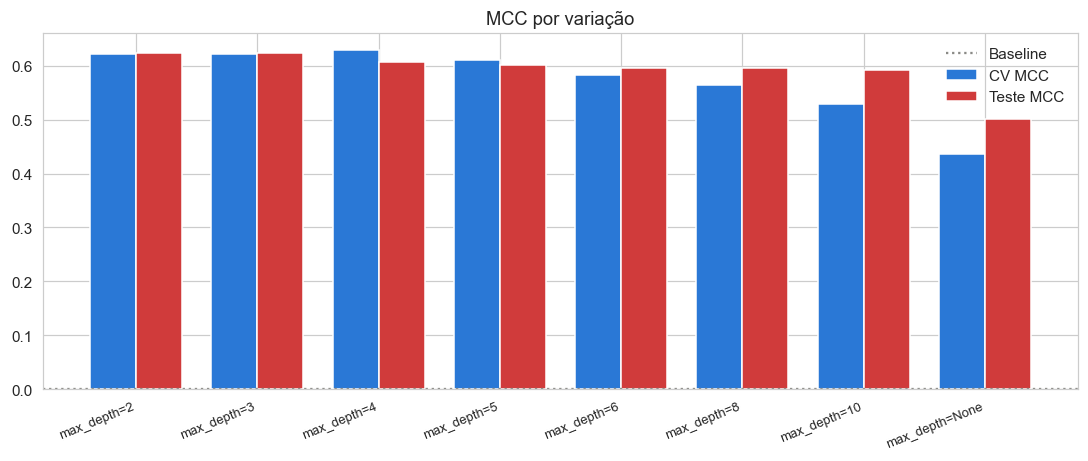

Onde a curva satura, aumentar o eixo só paga complexidade.
Bandas de IC sobrepostas: a ordenação entre variações não tem suporte estatístico.
Barra alta no gap: validação otimista frente ao holdout — sinal de overfitting.


In [9]:
eixo_numerico = len(RESULTADOS) > 1 and all(
    isinstance(r["valor"], (int, float, np.integer, np.floating)) for r in RESULTADOS
)

if eixo_numerico:
    ordenados = sorted(RESULTADOS, key=lambda r: r["valor"])
    xs = [r["valor"] for r in ordenados]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.3))

    ax1.plot(xs, [r["metricas_cv"]["MCC"] for r in ordenados], "o-", color="#2a78d6", label="CV")
    ax1.plot(xs, [r["metricas_teste"]["MCC"] for r in ordenados], "s--", color="#d03b3b", label="Teste")
    if BASELINE_METRICAS:
        ax1.axhline(BASELINE_METRICAS["MCC"], color="#8a8a86", linestyle=":", label="Baseline")
    ax1.set_xlabel(ordenados[0]["eixo"]); ax1.set_ylabel("MCC"); ax1.legend(frameon=False)
    ax1.set_title("MCC ao longo do eixo")

    aucs = [r["metricas_teste"]["AUC"] for r in ordenados]
    los = [r["metricas_teste"]["AUC_ic_low"] for r in ordenados]
    his = [r["metricas_teste"]["AUC_ic_high"] for r in ordenados]
    ax2.plot(xs, aucs, "o-", color="#4a3aa7")
    ax2.fill_between(xs, los, his, alpha=0.2, color="#4a3aa7", label="IC 95%")
    ax2.axhline(0.5, color="#8a8a86", linestyle=":", label="acaso")
    ax2.set_xlabel(ordenados[0]["eixo"]); ax2.set_ylabel("AUC"); ax2.legend(frameon=False)
    ax2.set_title("AUC no teste, com IC 95%")

    gaps = [r["metricas_cv"]["AUC"] - r["metricas_teste"]["AUC"] for r in ordenados]
    cores = ["#d03b3b" if g > 0.10 else "#eda100" if g > 0.05 else "#008300" for g in gaps]
    ax3.bar(range(len(gaps)), gaps, color=cores)
    ax3.set_xticks(range(len(xs))); ax3.set_xticklabels(xs, rotation=0)
    ax3.axhline(0, color="#8a8a86", linewidth=0.8)
    ax3.set_xlabel(ordenados[0]["eixo"]); ax3.set_ylabel("CV AUC − Teste AUC")
    ax3.set_title("Distância validação → holdout")
    plt.tight_layout(); plt.show()
else:
    fig, ax = plt.subplots(figsize=(10, 4.3))
    x = np.arange(len(RESULTADOS))
    largura = 0.38
    ax.bar(x - largura / 2, [r["metricas_cv"]["MCC"] for r in RESULTADOS], largura, label="CV MCC", color="#2a78d6")
    ax.bar(x + largura / 2, [r["metricas_teste"]["MCC"] for r in RESULTADOS], largura, label="Teste MCC", color="#d03b3b")
    if BASELINE_METRICAS:
        ax.axhline(BASELINE_METRICAS["MCC"], color="#8a8a86", linestyle=":", label="Baseline")
    ax.set_xticks(x); ax.set_xticklabels([r["variacao"] for r in RESULTADOS], rotation=22, ha="right", fontsize=8.5)
    ax.legend(frameon=False); ax.set_title("MCC por variação")
    plt.tight_layout(); plt.show()

print("Onde a curva satura, aumentar o eixo só paga complexidade.")
print("Bandas de IC sobrepostas: a ordenação entre variações não tem suporte estatístico.")
print("Barra alta no gap: validação otimista frente ao holdout — sinal de overfitting.")

## 8. Avaliação do campeão

ROC, Precisão-Recall e matriz de confusão em **contagens absolutas** — percentual
esconderia que a linha dos negativos tem poucos casos.

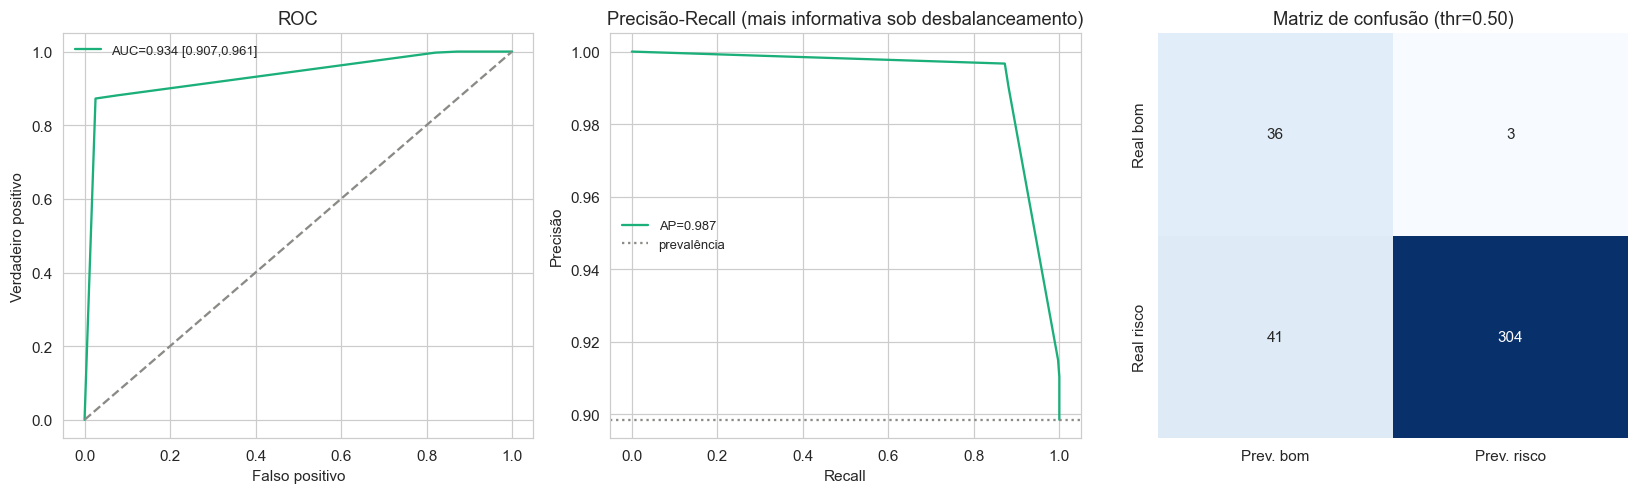

AUC 0.934 [0.907,0.961]  Recall(risco) 0.881 [0.843,0.911]  Specificity(bom) 0.923 [0.797,0.973]
BalAcc 0.902  MCC 0.607  Brier 0.087 (menor é melhor)

FN = 41 cliente(s) de risco NÃO detectado(s) — o erro caro do negócio.
FP = 3 bom(ns) pagador(es) marcado(s) como risco — atrito comercial.

Metas de negócio:
  OK  AUC: 0.934 (meta 0.75)
  OK  Recall: 0.881 (meta 0.70)
  OK  Accuracy: 0.885 (meta 0.65)

Accuracy do campeão não supera o baseline — comum sob classe majoritária e não invalida o modelo por si só. Leia MCC e balanced accuracy.


In [10]:
pipe, cols, met = CAMPEAO["pipeline"], CAMPEAO["features"], CAMPEAO["metricas_teste"]
y_proba, y_pred = met["y_proba"], met["y_pred"]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.6))

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color=COR_MODELO, label=f"AUC={met['AUC']:.3f} [{met['AUC_ic_low']:.3f},{met['AUC_ic_high']:.3f}]")
ax1.plot([0, 1], [0, 1], "--", color="#8a8a86")
ax1.set_xlabel("Falso positivo"); ax1.set_ylabel("Verdadeiro positivo")
ax1.set_title("ROC"); ax1.legend(frameon=False, fontsize=8.5)

prec, rec, _ = precision_recall_curve(y_test, y_proba)
prevalencia = float(y_test.mean())
ax2.plot(rec, prec, color=COR_MODELO, label=f"AP={met['AP']:.3f}")
ax2.axhline(prevalencia, color="#8a8a86", linestyle=":", label="prevalência")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precisão")
ax2.set_title("Precisão-Recall (mais informativa sob desbalanceamento)")
ax2.legend(frameon=False, fontsize=8.5)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax3,
           xticklabels=["Prev. bom", "Prev. risco"], yticklabels=["Real bom", "Real risco"])
ax3.set_title(f"Matriz de confusão (thr={met['threshold']:.2f})")
plt.tight_layout(); plt.show()

tn, fp, fn_, tp = cm.ravel()
print(f"AUC {met['AUC']:.3f} [{met['AUC_ic_low']:.3f},{met['AUC_ic_high']:.3f}]  "
      f"Recall(risco) {met['Recall']:.3f} [{met['Recall_ic_low']:.3f},{met['Recall_ic_high']:.3f}]  "
      f"Specificity(bom) {met['Specificity']:.3f} [{met['Specificity_ic_low']:.3f},{met['Specificity_ic_high']:.3f}]")
print(f"BalAcc {met['Balanced_Accuracy']:.3f}  MCC {met['MCC']:.3f}  Brier {met['Brier']:.3f} (menor é melhor)")
print(f"\nFN = {fn_} cliente(s) de risco NÃO detectado(s) — o erro caro do negócio.")
print(f"FP = {fp} bom(ns) pagador(es) marcado(s) como risco — atrito comercial.")

print("\nMetas de negócio:")
for chave, meta_alvo in [("AUC", METAS_KPI["auc_roc"]), ("Recall", METAS_KPI["recall_classe1"]),
                         ("Accuracy", METAS_KPI["accuracy"])]:
    ok = met[chave] >= meta_alvo
    print(f"  {'OK ' if ok else 'X  '} {chave}: {met[chave]:.3f} (meta {meta_alvo:.2f})")

if BASELINE_METRICAS and met["Accuracy"] <= BASELINE_METRICAS["Accuracy"]:
    print("\nAccuracy do campeão não supera o baseline — comum sob classe majoritária "
          "e não invalida o modelo por si só. Leia MCC e balanced accuracy.")

## 9. Importância das variáveis e checagem de vazamento

Importância por redução de impureza: quanto cada variável, somada em todos os
nós que a usam, reduziu a mistura de classes. Favorece variáveis de alta
cardinalidade — leia como ordem de grandeza, não como ranking exato.

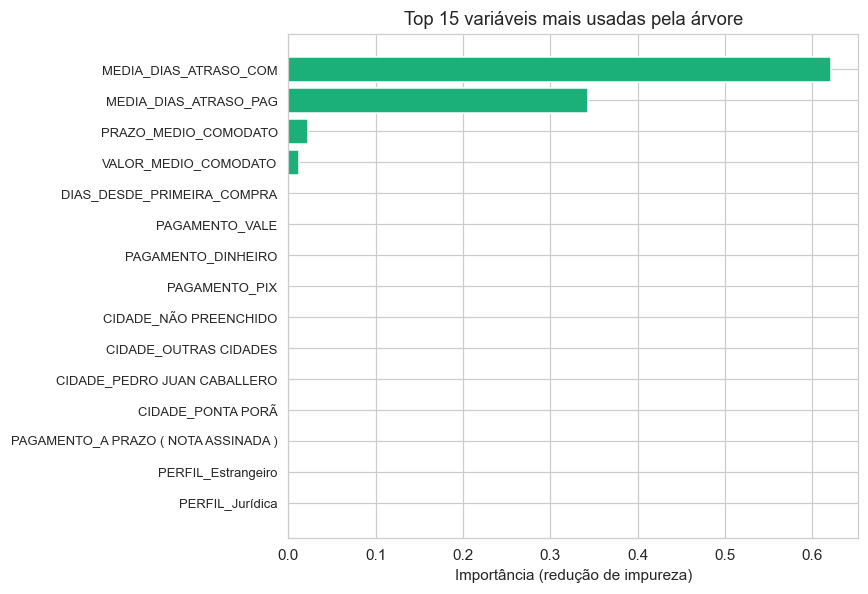

Top 8 por importância:
  MEDIA_DIAS_ATRASO_COM        0.6215
  MEDIA_DIAS_ATRASO_PAG        0.3437
  PRAZO_MEDIO_COMODATO         0.0228
  VALOR_MEDIO_COMODATO         0.0118
  DIAS_DESDE_PRIMEIRA_COMPRA   0.0002
  FREQUENCIA_COMPRAS           0.0000
  TICKET_MEDIO                 0.0000
  TOTAL_GASTO                  0.0000

ATENÇÃO: ['MEDIA_DIAS_ATRASO_COM', 'MEDIA_DIAS_ATRASO_PAG'] — feature derivada do alvo no topo do ranking.
É o vazamento parcial reconhecido (ver seção final). Rode ESTUDO='ablacao' para medir quanto do desempenho vem daí.


In [11]:
def nomes_features(pipeline, features_num, features_cat):
    """Nomes das colunas APÓS o one-hot — sem isso a importância não tem rótulo."""
    prep = pipeline.named_steps["prep"]
    try:
        cat_names = list(prep.named_transformers_["cat"].get_feature_names_out(features_cat))
    except Exception:
        cat_names = list(features_cat)
    return list(features_num) + cat_names


fn_campeao = [c for c in cols if c in FEATURES_NUM]
fc_campeao = [c for c in cols if c in FEATURES_CAT]
nomes = nomes_features(pipe, fn_campeao, fc_campeao)
importancias = pipe.named_steps["clf"].feature_importances_

ordem = np.argsort(importancias)[-15:]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(range(len(ordem)), importancias[ordem], color=COR_MODELO)
ax.set_yticks(range(len(ordem))); ax.set_yticklabels([nomes[i] for i in ordem], fontsize=8.5)
ax.set_xlabel("Importância (redução de impureza)")
ax.set_title("Top 15 variáveis mais usadas pela árvore")
plt.tight_layout(); plt.show()

top_abs = sorted(zip(nomes, importancias), key=lambda t: -t[1])[:8]
print("Top 8 por importância:")
for nome, valor in top_abs:
    print(f"  {nome:<28} {valor:.4f}")

topo3 = {n for n, _ in top_abs[:3]}
vazamento_no_topo = [n for n in topo3 if "ATRASO" in n.upper()]
if vazamento_no_topo:
    print(f"\nATENÇÃO: {vazamento_no_topo} — feature derivada do alvo no topo do ranking.")
    print("É o vazamento parcial reconhecido (ver seção final). Rode ESTUDO='ablacao' "
          "para medir quanto do desempenho vem daí.")

## 10. A árvore campeã, desenhada e em texto

A vantagem que a Regressão Logística não tem: a regra pode ser **lida**. Cada
nó mostra a condição, quantos clientes chegam ali e a distribuição entre as
classes.

> Folhas com pouquíssimos clientes são o sinal visual de overfitting — uma
> decisão apoiada em três casos não é uma regra de negócio.

Árvore campeã: profundidade 4 · 6 folhas


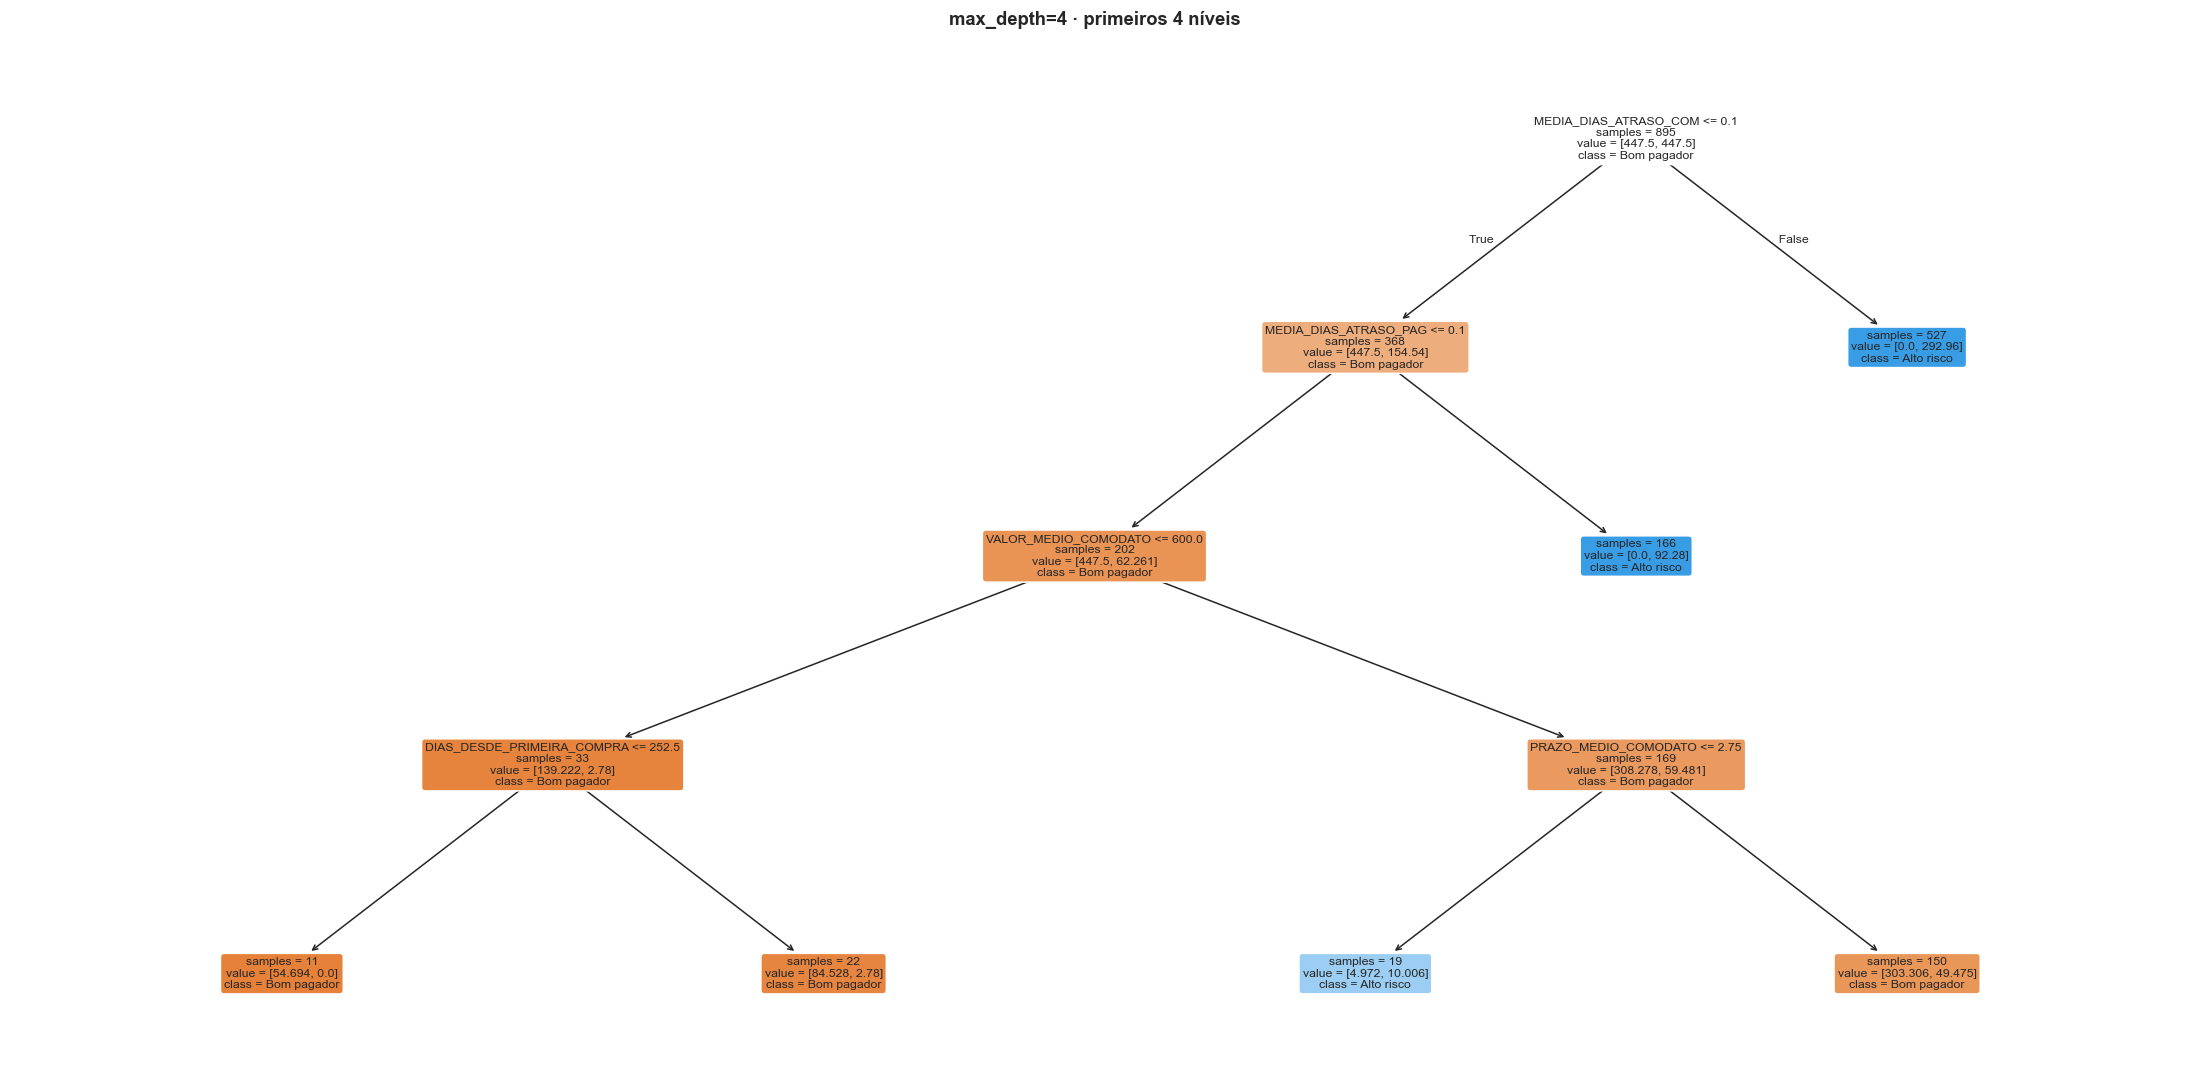


Clientes por folha: mínimo 11 · mediana 86 · máximo 527

Nenhuma folha com menos de 5 clientes — as regras têm sustentação.

Regras em texto (topo da árvore):
|--- MEDIA_DIAS_ATRASO_COM <= 0.10
|   |--- MEDIA_DIAS_ATRASO_PAG <= 0.10
|   |   |--- VALOR_MEDIO_COMODATO <= 600.00
|   |   |   |--- DIAS_DESDE_PRIMEIRA_COMPRA <= 252.50
|   |   |   |   |--- class: 0
|   |   |   |--- DIAS_DESDE_PRIMEIRA_COMPRA >  252.50
|   |   |   |   |--- class: 0
|   |   |--- VALOR_MEDIO_COMODATO >  600.00
|   |   |   |--- PRAZO_MEDIO_COMODATO <= 2.75
|   |   |   |   |--- class: 1
|   |   |   |--- PRAZO_MEDIO_COMODATO >  2.75
|   |   |   |   |--- class: 0
|   |--- MEDIA_DIAS_ATRASO_PAG >  0.10
|   |   |--- class: 1
|--- MEDIA_DIAS_ATRASO_COM >  0.10
|   |--- class: 1



In [12]:
arvore = pipe.named_steps["clf"]
profundidade, folhas = arvore.get_depth(), arvore.get_n_leaves()
print(f"Árvore campeã: profundidade {profundidade} · {folhas} folhas")

# Acima de 4 níveis o desenho fica ilegível; o topo concentra as decisões que
# afetam mais clientes.
prof_desenho = min(profundidade, 4)
if profundidade > prof_desenho:
    print(f"(desenhando os {prof_desenho} primeiros níveis — o topo concentra as "
          "decisões que afetam mais clientes)")

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(arvore, max_depth=prof_desenho, feature_names=nomes,
         class_names=["Bom pagador", "Alto risco"],
         filled=True, rounded=True, fontsize=8, proportion=False, impurity=False, ax=ax)
ax.set_title(f"{CAMPEAO['variacao']} · primeiros {prof_desenho} níveis", fontweight="bold")
plt.tight_layout(); plt.show()

# Folhas frágeis: o overfitting em número, mais objetivo que olhar o desenho.
n_por_folha = arvore.tree_.n_node_samples[arvore.tree_.children_left == -1]
fragil = int((n_por_folha < 5).sum())
print(f"\nClientes por folha: mínimo {int(n_por_folha.min())} · mediana "
      f"{int(np.median(n_por_folha))} · máximo {int(n_por_folha.max())}")
if fragil:
    print(f"\nATENÇÃO: {fragil} de {folhas} folhas têm menos de 5 clientes — "
          "regras apoiadas em coincidência. Aumente min_samples_leaf ou reduza "
          "max_depth para regras que se sustentem em produção.")
else:
    print("\nNenhuma folha com menos de 5 clientes — as regras têm sustentação.")

print(f"\nRegras em texto (topo da árvore):")
print(export_text(arvore, feature_names=list(nomes), max_depth=3, decimals=2))

## 11. Exportação do campeão

Local: `pickle` do pipeline treinado, ao lado do split. Databricks: log do
modelo no MLflow e registro no Model Registry — a cópia durável, porque o
disco do serverless é efêmero entre sessões.

O `model_card` carrega toda a configuração + métricas + limitações junto do
modelo: **um modelo sem a configuração que o produziu não é auditável**.

In [13]:
MODEL_CARD = {
    "nome_modelo": NOME_MODELO, "algoritmo": CLASSE_MODELO.__name__,
    "variacao_campea": CAMPEAO["variacao"], "estudo": ESTUDO,
    "hiperparametros": CAMPEAO["hp"], "preproc": PREPROC,
    "features": CAMPEAO["features"], "target": TARGET,
    "threshold_classificacao": THRESHOLD["classificacao"],
    "threshold_otimo_oof": CAMPEAO["threshold_otimo_oof"],
    "faixas_risco": {"baixo": THRESHOLD["faixa_baixo"], "medio": THRESHOLD["faixa_medio"]},
    "data_version": DATA_VERSION, "random_state": RANDOM_STATE,
    "metricas_teste": {k: v for k, v in met.items() if isinstance(v, (int, float))},
    "metricas_cv": CAMPEAO["metricas_cv"],
}

if EM_DATABRICKS:
    if mlflow.active_run() is not None:
        mlflow.end_run()
    mlflow.set_experiment(EXPERIMENT_NAME)
    with mlflow.start_run(run_name=f"{SLUG_MODELO}__{ESTUDO}__{DATA_VERSION}") as run:
        mlflow.log_params({f"hp.{k}": v for k, v in CAMPEAO["hp"].items()})
        mlflow.log_metrics({k: v for k, v in MODEL_CARD["metricas_teste"].items()})
        mlflow.log_dict(MODEL_CARD, "model_card.json")
        assinatura = infer_signature(X_train[cols], pipe.predict(X_train[cols]))
        mlflow.sklearn.log_model(sk_model=pipe, name="modelo", signature=assinatura,
                                 input_example=X_train[cols].head(3))
        try:
            mlflow.register_model(model_uri=f"runs:/{run.info.run_id}/modelo", name=NOME_REGISTRADO)
            print(f"Registrado em {NOME_REGISTRADO}")
        except Exception as e:
            print(f"Registro no Model Registry falhou ({type(e).__name__}); modelo acessível via "
                  f"runs:/{run.info.run_id}/modelo")
        print(f"Run: {run.info.run_id}")
else:
    saida = Path(PASTA_SAIDA.strip()) if PASTA_SAIDA.strip() else caminho_split.parent
    caminho_pkl = saida / f"modelo_{SLUG_MODELO}_v{DATA_VERSION.replace('.', '_')}.pkl"
    with open(caminho_pkl, "wb") as f:
        pickle.dump({"pipeline": pipe, "model_card": MODEL_CARD}, f)
    print(f"{caminho_pkl.name}")
    print(f"  {CAMPEAO['variacao']} — MCC {met['MCC']:.3f}  AUC {met['AUC']:.3f}")

print(f"\nPara escorar: prob = pipeline.predict_proba(df[{cols}])[:, 1]")
print(f"  risco = 'ALTO' se prob >= {THRESHOLD['faixa_medio']}, "
      f"'MÉDIO' se >= {THRESHOLD['faixa_baixo']}, senão 'BAIXO'")

modelo_arvore_decisao_v1_0.pkl
  max_depth=4 — MCC 0.607  AUC 0.934

Para escorar: prob = pipeline.predict_proba(df[['FREQUENCIA_COMPRAS', 'TICKET_MEDIO', 'TOTAL_GASTO', 'DIAS_DESDE_PRIMEIRA_COMPRA', 'DIAS_DESDE_ULTIMA_COMPRA', 'TOTAL_PARCELAS', 'TOTAL_COMODATOS', 'PCT_COMPRAS_A_PRAZO', 'PRAZO_MEDIO_COMODATO', 'VALOR_MEDIO_COMODATO', 'MEDIA_DIAS_ATRASO_PAG', 'MEDIA_DIAS_ATRASO_COM', 'PERFIL', 'CIDADE', 'PAGAMENTO']])[:, 1]
  risco = 'ALTO' se prob >= 0.65, 'MÉDIO' se >= 0.35, senão 'BAIXO'
